In [4]:
#from google.colab import drive
#drive.mount('/content/drive')

---
# 1. 필요한 라이브러리 설치 및 임포트

In [5]:
!apt-get -qq update
!apt-get -qq install fonts-nanum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 시각화 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지
sns.set(style='whitegrid')

zsh:1: command not found: apt-get
zsh:1: command not found: apt-get


# 2. 데이터 준비

In [6]:
# ① CSV 불러오기
data = pd.read_csv("/content/drive/MyDrive/capstone1_code/processed_data.csv")

print("전체 데이터 크기:", data.shape)
print(data[['Label', 'Attack']].head())

# Label: 0=정상, 1=공격
normal_df = data[data["Label"] == 0].copy()
attack_df = data[data["Label"] == 1].copy()

print("정상 데이터 수:", len(normal_df))
print("공격  데이터 수:", len(attack_df))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/capstone1_code/processed_data.csv'

## 2.2 정상 데이터중 100,000개만 훈련에 사용

In [ ]:
# 최대 100,000개까지만 정상 데이터 사용
max_train_normal = 100_000

train_normal_df = normal_df.sample(
    n=min(max_train_normal, len(normal_df)),
    random_state=42
)

print("학습에 사용할 정상 데이터 수:", len(train_normal_df))

학습에 사용할 정상 데이터 수: 100000


## 2.3 테스트 데이터셋 구성

In [ ]:
test_normal_df = normal_df.drop(train_normal_df.index)

test_df = pd.concat([test_normal_df, attack_df])
test_df = test_df.sample(frac=1, random_state=42)

print("테스트 데이터 수 (정상+공격):", len(test_df))

테스트 데이터 수 (정상+공격): 2265424


In [ ]:
drop_cols = ["Label", "Attack"]  # Attack 문자열, Label은 제거
feature_cols = [c for c in data.columns if c not in drop_cols]

X_train = train_normal_df[feature_cols]
X_test  = test_df[feature_cols]
y_test  = test_df["Label"]

# 3. One-Class SVM 모델 구현 및 학습

## 3.1. 데이터 스케일링

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.2. One-Class SVM 모델 정의
- nu : 이상치로 간주할 데이터 비율
- kernel : 커널 함수('rbf', 'linear', 'poly', 'sigmoid')
- gamma : RBF 커널의 파라미터

In [ ]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    nu=0.01,
    kernel='rbf',
    gamma='scale'
)

print("모델 학습 중...")
ocsvm.fit(X_train_scaled)
print("학습 완료!")

모델 학습 중...
학습 완료!


## 3.3. 모델 예측 및 모델 출력값 변경

In [ ]:
pred_train = ocsvm.predict(X_train_scaled)
pred_test = ocsvm.predict(X_test_scaled)

# 모델 예측(1 : 정상, -1 : 이상치로 출력됨) -> np.where를 사용해서 -1이면 1로바꾸고, 1이면 0으로 바꿔줌!
pred_train = np.where(pred_train == -1, 1, 0)
pred_test = np.where(pred_test == -1, 1, 0)

#신뢰도 점수 계산
score_train = ocsvm.decision_function(X_train_scaled)
score_test = ocsvm.decision_function(X_test_scaled)

# 4, 모델 평가

## 4.1. 혼동 행렬 & 분류 보고서

테스트 데이터에 대한 평가 결과:

혼동 행렬:
[[2115376   22355]
 [     14  127679]]

분류 보고서:
              precision    recall  f1-score   support

          정상       1.00      0.99      0.99   2137731
          공격       0.85      1.00      0.92    127693

    accuracy                           0.99   2265424
   macro avg       0.93      0.99      0.96   2265424
weighted avg       0.99      0.99      0.99   2265424



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing f

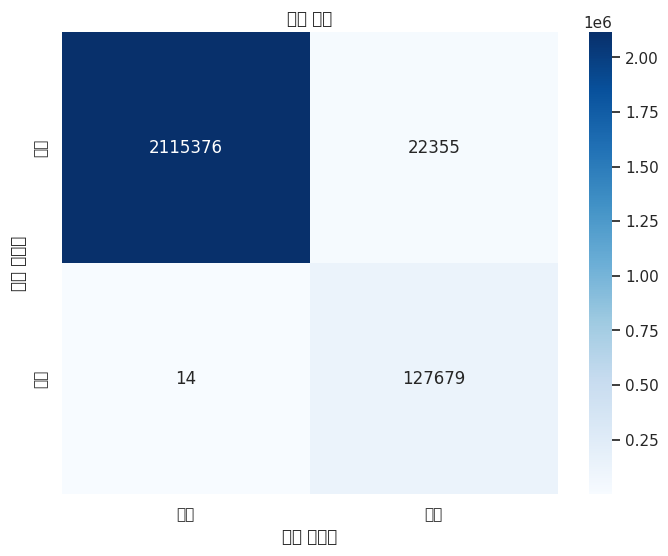

In [ ]:
print("테스트 데이터에 대한 평가 결과:")

print("\n혼동 행렬:")
cm = confusion_matrix(y_test, pred_test)
print(cm)

print("\n분류 보고서:")
target_names = ['정상', '공격']  # 0, 1 순서
print(classification_report(y_test, pred_test, target_names=target_names))

# 시각화: 혼동 행렬
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('혼동 행렬')
plt.ylabel('실제 클래스')
plt.xlabel('예측 클래스')
plt.show()

## 4.2. ROC 곡선 & AUC

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

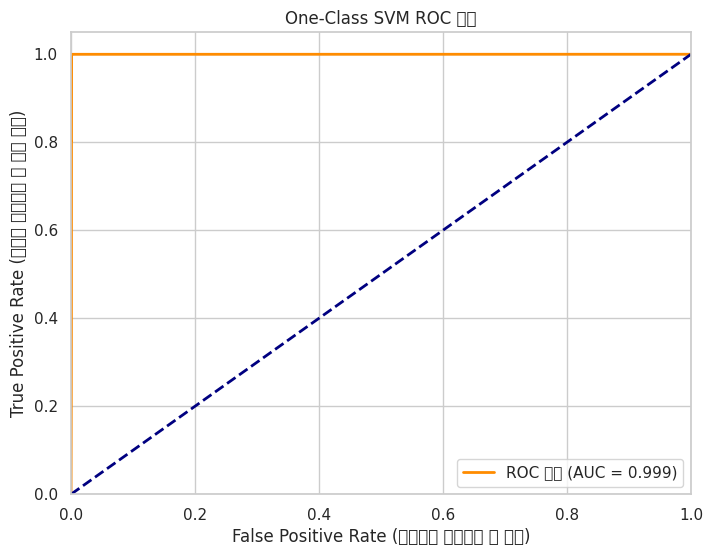

In [ ]:
# 점수 방향 뒤집기: 값이 클수록 '공격(1)'에 가깝도록
score_for_roc = -score_test

fpr, tpr, _ = roc_curve(y_test, score_for_roc)  # 기본 pos_label=1
roc_auc = auc(fpr, tpr)

# 시각화: ROC 곡선
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC 곡선 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (공격인데 정상으로 본 비율)')
plt.ylabel('True Positive Rate (공격을 공격으로 잘 맞춘 비율)')
plt.title('One-Class SVM ROC 곡선')
plt.legend(loc="lower right")
plt.show()

# 5. 이상치 탐지 시각화 및 분석

## 5.1. 신뢰도 점수 분포 시각화
- **score > 0 : 정상에 가깝다.**
- **score < 0 : 공격에 가깝다.**

/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 47280 (\N{HANGUL SYLLABLE ROE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3229512389.py:18: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout

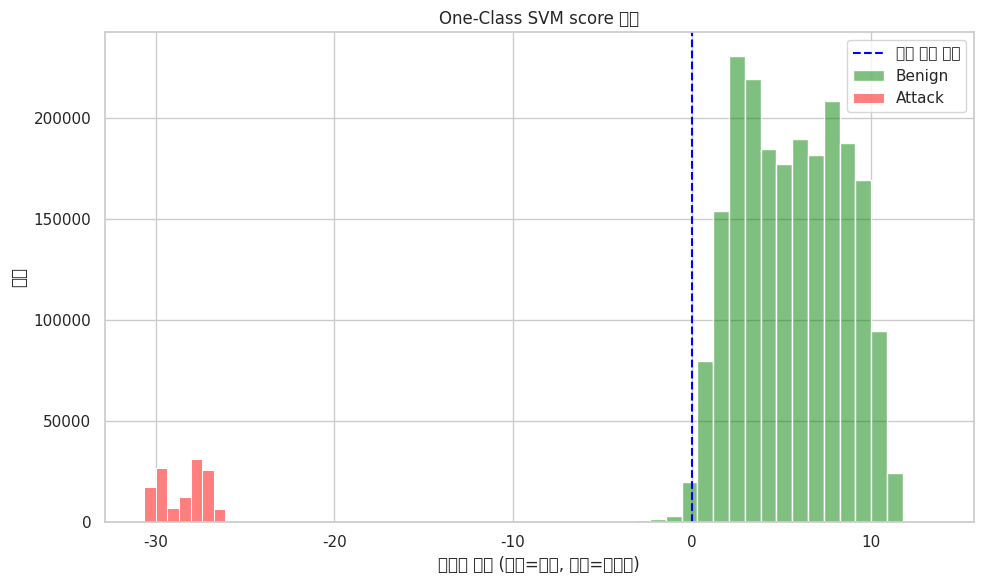

In [ ]:
plt.figure(figsize=(10, 6))

# 정상 (0) → 초록
sns.histplot(score_test[y_test == 0], color='green', alpha=0.5,
             label='Benign', bins=50)

# 공격 (1) → 빨강
sns.histplot(score_test[y_test == 1], color='red', alpha=0.5,
             label='Attack', bins=50)

# 기본 OCSVM의 결정 경계는 score=0
plt.axvline(x=0, color='blue', linestyle='--', label='기본 결정 경계')

plt.legend()
plt.title('One-Class SVM score 분포')
plt.xlabel('신뢰도 점수 (양수=정상, 음수=이상치)')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

## 5.1. 모델이 공격(1)이라고 예측한 데이터 분석

In [ ]:
# DataFrame 인덱스를 리셋해서 오류 방지
X_test_df = X_test.reset_index(drop=True)
y_test_series = pd.Series(y_test)

# 공격(1)이라고 탐지된 것만 모으기
detected_attack = X_test_df[pred_test == 1].copy()
detected_attack["실제_Label"] = y_test_series[pred_test == 1].values
detected_attack["신뢰도_점수"] = score_test[pred_test == 1]

print("탐지된 공격 샘플 (신뢰도 낮은 순 상위 10개):")
print(detected_attack.sort_values("신뢰도_점수").head(10))

탐지된 공격 샘플 (신뢰도 낮은 순 상위 10개):
         FLOW_START_MILLISECONDS  FLOW_END_MILLISECONDS  L4_SRC_PORT  \
2096339            1424246035372          1424246035372        11326   
46242              1424233617566          1424233617566        11421   
692375             1424225828128          1424225828128         4963   
2176677            1424243960491          1424243960491        43565   
46634              1424241708720          1424241708720        16705   
328044             1424250028289          1424250028289         1707   
328009             1421929204125          1421929204125        62365   
1839760            1424248500378          1424248500857        32287   
1840047            1424227251654          1424227251654        58231   
2177059            1424237021622          1424237021900        50185   

         L4_DST_PORT  PROTOCOL  IN_BYTES  IN_PKTS  OUT_BYTES  OUT_PKTS  \
2096339           67        17  0.537656        2  -3.116464         0   
46242            514        17

## 5.3. 오탐 분석

In [ ]:
false_positives = detected_attack[detected_attack["실제_Label"] == 0]

print(f"\n오탐(False Positive) 건수: {len(false_positives)}")
print(f"전체 정상 중 비율: {len(false_positives) / sum(y_test==0) * 100:.2f}%")


오탐(False Positive) 건수: 22355
전체 정상 중 비율: 1.05%


## 5.4. 미탐 분석

In [ ]:
false_neg_mask = (pred_test == 0) & (y_test == 1)
false_negatives = X_test[false_neg_mask]

print(f"\n미탐(False Negative) 건수: {len(false_negatives)}")
print(f"전체 공격 중 비율: {len(false_negatives) / sum(y_test==1) * 100:.2f}%")


미탐(False Negative) 건수: 14
전체 공격 중 비율: 0.01%


# 6. 파라미터 튜닝 및 최적화

## 6.1. 커스텀 점수 함수 정의(공격=1이 Positive)

In [ ]:
def anomaly_detection_score(y_true, y_pred_raw):
    """
    OCSVM은 1=정상, -1=이상치로 출력하므로
    이를 0=정상, 1=공격으로 변환한 뒤 F1 계산한다.
    """
    # OCSVM 출력값을 Flow 데이터 라벨 체계로 변환
    y_pred = np.where(y_pred_raw == -1, 1, 0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return f1

## 6.2. 교차 검증용 데이터 구성

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# CV 정상 샘플 5만 + 공격 샘플 500개
cv_normal = train_normal_df.sample(n=100000, random_state=42)
cv_attack = attack_df.sample(n=min(1000, len(attack_df)), random_state=42)

cv_data = pd.concat([cv_normal, cv_attack], ignore_index=True)
cv_data = cv_data.sample(frac=1, random_state=42).reset_index(drop=True)

X_cv = cv_data[feature_cols]
y_cv = cv_data["Label"]

# 스케일러로 변환
X_cv_scaled = scaler.transform(X_cv)

print("CV 데이터 구성 완료:", X_cv_scaled.shape)
print("정상:공격 =", np.bincount(y_cv))

CV 데이터 구성 완료: (101000, 50)
정상:공격 = [100000   1000]


## 8.3. GridSearch 파라미터 설정

In [ ]:
param_grid = {
    "nu": [0.01, 0.05, 0.1, 0.2],
    "kernel": ["rbf"],
    "gamma": ["scale", "auto", 0.1, 0.01, 0.001]
}

custom_scorer = make_scorer(anomaly_detection_score)

## 8.4. GridSearchCV 실행

In [ ]:
print("파라미터 튜닝 중... (시간 조금 걸림)")

ocsvm_base = OneClassSVM()

grid_search = GridSearchCV(
    estimator=ocsvm_base,
    param_grid=param_grid,
    scoring=custom_scorer,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_cv_scaled, y_cv)

print("최적 파라미터:", grid_search.best_params_)
print("최고 점수:", grid_search.best_score_)

파라미터 튜닝 중... (시간 조금 걸림)


## 8.5. 최적 OCSVM으로 재학습

In [ ]:
best_ocsvm = OneClassSVM(**grid_search.best_params_)
best_ocsvm.fit(X_train_scaled)

print("최적 모델 학습 완료!")

## 8.6. 최종 테스트셋에서 평가

In [ ]:
best_raw_pred = best_ocsvm.predict(X_test_scaled)
best_pred_test = np.where(best_raw_pred == -1, 1, 0)

print("\n최적화된 모델 성능:")
print(classification_report(y_test, best_pred_test, target_names=["정상","공격"]))

# 9. 모델 저장 및 불러오기

## 9.1. 스케일러 + 모델 + 메타데이터 함께 저장

In [ ]:
import joblib
import datetime

model_version = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

model_info = {
    "model": best_ocsvm,
    "scaler": scaler,
    "train_date": datetime.datetime.now(),
    "model_version": model_version,
    "parameters": best_ocsvm.get_params(),
    "features": feature_cols
}

model_filename = f"ocsvm_flow_model_{model_version}.pkl"
joblib.dump(model_info, model_filename)

print(f"모델 저장 완료: {model_filename}")

## 9.2. 저장된 모델 불러오기

In [ ]:
loaded = joblib.load(model_filename)

loaded_ocsvm = loaded["model"]
loaded_scaler = loaded["scaler"]

print("불러온 모델 버전:", loaded["model_version"])

## 9.3. 새로운 Flow 데이터에 적용 예시

In [ ]:
# 새로운 데이터 1개 예시
new_data = pd.DataFrame([X_test.iloc[0].values], columns=feature_cols)

new_scaled = loaded_scaler.transform(new_data)
new_pred_raw = loaded_ocsvm.predict(new_scaled)[0]
new_score = loaded_ocsvm.decision_function(new_scaled)[0]

result = "정상" if new_pred_raw == 1 else "공격"

print(f"새 데이터 예측 결과 → {result} (score={new_score:.4f})")